In [1]:
import pandas as pd

In [41]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [38]:
df['Sex'] = df['Sex'].replace(1, "Male")
df['Sex'] = df['Sex'].replace(0, "Female")
df.drop(columns=["id"])

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,Male,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,Male,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,Female,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,Female,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,Male,4,140,234,0,2,125,1,3.8,2,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,56,Female,1,110,226,0,0,132,0,0.0,1,0,7,0
629996,54,Male,4,128,249,1,2,150,0,0.0,2,0,3,0
629997,67,Male,4,130,275,0,0,149,0,0.0,1,2,7,1
629998,52,Male,4,140,199,0,2,157,0,0.0,1,0,6,1


In [15]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,Male,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,Male,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,Female,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,Female,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,Male,4,140,234,0,2,125,1,3.8,2,3,3,1


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  object 
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease  

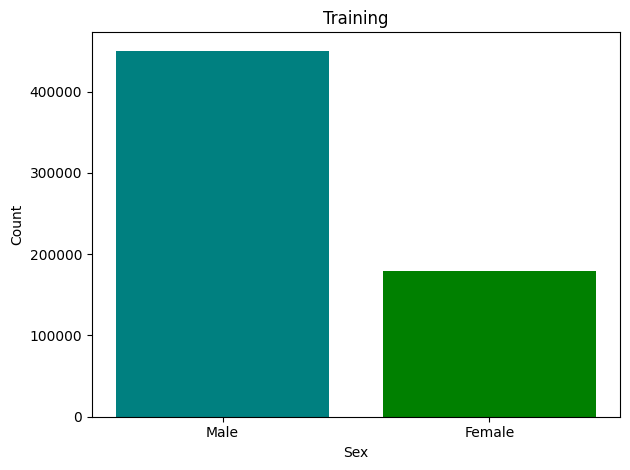

In [20]:
import matplotlib.pyplot as plt

counts = df["Sex"].value_counts()

plt.bar(counts.index, counts.values, color=["teal", "green"])
plt.title("Training")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [26]:
df.columns.tolist()

['id',
 'Age',
 'Sex',
 'Chest pain type',
 'BP',
 'Cholesterol',
 'FBS over 120',
 'EKG results',
 'Max HR',
 'Exercise angina',
 'ST depression',
 'Slope of ST',
 'Number of vessels fluro',
 'Thallium',
 'Heart Disease']

In [35]:
X = df.drop('Heart Disease', axis=1) 
y = df["Heart Disease"]
y = y.map({'Presence': 1, 'Absence': 0}).fillna(y).astype(int)

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ['Age', 'BP', 'Cholesterol']
categorical_features = ['Sex', 'Chest pain type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier())
])

In [48]:
model = pipeline.fit(X_train, y_train)

In [49]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     69564
           1       0.76      0.75      0.75     56436

    accuracy                           0.78    126000
   macro avg       0.78      0.78      0.78    126000
weighted avg       0.78      0.78      0.78    126000



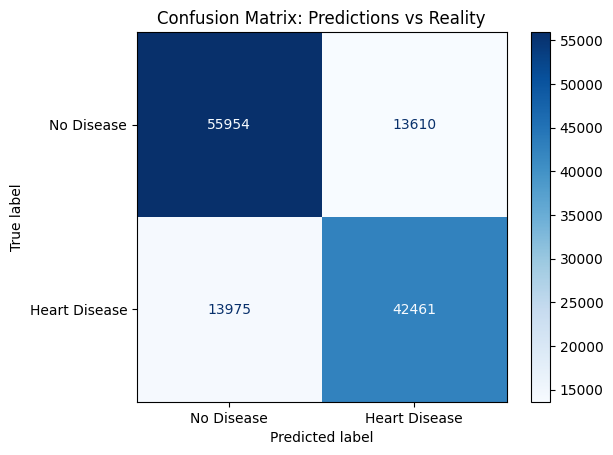

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Heart Disease'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Predictions vs Reality")
plt.show()

In [54]:
import joblib as jb
jb.dump(model, "HeartDiseasePredicter.pkl")

['HeartDiseasePredicter.pkl']